# Análisis de Correlación con Variable Objetivo
## Features Engineered vs Rendimiento

Este notebook analiza en detalle la correlación entre todas las features creadas durante el Feature Engineering y la variable objetivo (rendimiento).

### Objetivos:
1. Calcular correlaciones de todas las features con rendimiento
2. Clasificar features por fuerza de correlación
3. Analizar correlaciones por categoría de features
4. Identificar las features más importantes para predicción
5. Detectar redundancias (multicolinealidad)
6. Generar recomendaciones de feature selection

---

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries importadas correctamente")

✅ Libraries importadas correctamente


## 1. Carga de Datos con Features

In [3]:
# Cargar dataset con features engineered
print("="*80)
print("CARGA DE DATASET CON FEATURES")
print("="*80)

df = pd.read_csv('dataset_final_clima_completo.csv')

print(f"\n📊 Dataset cargado:")
print(f"  Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} columnas")
print(f"  Memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# Verificar que existe la variable objetivo
if 'rendimiento' in df.columns:
    print(f"\n✅ Variable objetivo encontrada: 'rendimiento'")
    print(f"  Registros válidos: {df['rendimiento'].notna().sum():,}")
    print(f"  Valores faltantes: {df['rendimiento'].isna().sum():,}")
else:
    print("\n⚠️ ERROR: Variable 'rendimiento' no encontrada")

print(f"\n📋 Columnas totales: {len(df.columns)}")
df.head()

CARGA DE DATASET CON FEATURES

📊 Dataset cargado:
  Dimensiones: 1,441,934 registros × 15 columnas
  Memoria: 532.50 MB

✅ Variable objetivo encontrada: 'rendimiento'
  Registros válidos: 1,441,934
  Valores faltantes: 0

📋 Columnas totales: 15


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,1,3333,22.368317,5.617142,34.550898,66.545659,77.879491,No sodico,10,3
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,2,3333,23.294342,1.991272,34.550898,66.545659,77.879491,No sodico,10,3
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,3,3333,19.947906,6.193161,34.550898,66.545659,77.879491,No sodico,10,3
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,4,3333,18.099762,3.725052,34.550898,66.545659,77.879491,No sodico,10,3
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,5,3333,12.083649,0.638962,34.550898,66.545659,77.879491,No sodico,10,3


In [4]:
# Identificar features numéricas (excluyendo target y metadata)
print("="*80)
print("IDENTIFICACIÓN DE FEATURES PARA ANÁLISIS")
print("="*80)

# Columnas a excluir del análisis
exclude_cols = [
    'rendimiento',  # Target
    'provincia_nombre',
    'departamento_nombre',
    'departamento_id',
    'cultivo',
    'estacion',
    'suelo_alcalin_s1',
    'produccion',  # Leakage potencial
    'sup_sembrada'  # Leakage potencial
]

# Features numéricas
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col not in exclude_cols]

print(f"\n📊 Features numéricas identificadas: {len(numeric_features)}")
print(f"\n📋 Categorías de features:")

# Clasificar features por categoría
temporal_features = [col for col in numeric_features if any(x in col for x in ['año', 'mes', 'trim', 'sem', 'decada'])]
clima_features = [col for col in numeric_features if any(x in col for x in ['temp', 'precip', 'clima', 'evapo', 'balance', 'seco'])]
suelo_features = [col for col in numeric_features if 'suelo' in col]
encoding_features = [col for col in numeric_features if 'encoded' in col or ('mean' in col and 'rendimiento' not in col) or 'frecuencia' in col]
lag_features = [col for col in numeric_features if 'lag' in col]
roll_features = [col for col in numeric_features if 'roll' in col]
interaction_features = [col for col in numeric_features if '_x_' in col or 'ratio' in col]
poly_features = [col for col in numeric_features if '_sq' in col]

# Features que no caen en las categorías anteriores
all_categorized = (temporal_features + clima_features + suelo_features + 
                   encoding_features + lag_features + roll_features + 
                   interaction_features + poly_features)
other_features = [col for col in numeric_features if col not in all_categorized]

print(f"  - Temporales: {len(temporal_features)}")
print(f"  - Climáticas: {len(clima_features)}")
print(f"  - Suelo: {len(suelo_features)}")
print(f"  - Encoding: {len(encoding_features)}")
print(f"  - Lags: {len(lag_features)}")
print(f"  - Rolling: {len(roll_features)}")
print(f"  - Interacciones: {len(interaction_features)}")
print(f"  - Polinomiales: {len(poly_features)}")
print(f"  - Otras: {len(other_features)}")

print(f"\n✅ Total features para análisis: {len(numeric_features)}")

IDENTIFICACIÓN DE FEATURES PARA ANÁLISIS

📊 Features numéricas identificadas: 7

📋 Categorías de features:
  - Temporales: 2
  - Climáticas: 2
  - Suelo: 3
  - Encoding: 0
  - Lags: 0
  - Rolling: 0
  - Interacciones: 0
  - Polinomiales: 0
  - Otras: 0

✅ Total features para análisis: 7


## 2. Análisis de Correlación Global

In [5]:
# Calcular correlaciones con rendimiento
print("="*80)
print("CORRELACIÓN DE TODAS LAS FEATURES CON RENDIMIENTO")
print("="*80)

# Preparar datos (solo registros con rendimiento válido)
df_valid = df[df['rendimiento'].notna()].copy()

print(f"\nRegistros válidos para análisis: {len(df_valid):,}")

# Calcular correlaciones de Pearson
correlations = {}
p_values = {}

for col in numeric_features:
    # Filtrar valores válidos para ambas variables
    valid_data = df_valid[[col, 'rendimiento']].dropna()
    
    if len(valid_data) > 10:  # Mínimo de datos para calcular correlación
        corr, pval = pearsonr(valid_data[col], valid_data['rendimiento'])
        correlations[col] = corr
        p_values[col] = pval
    else:
        correlations[col] = np.nan
        p_values[col] = np.nan

# Crear DataFrame con resultados
corr_df = pd.DataFrame({
    'Feature': list(correlations.keys()),
    'Correlación': list(correlations.values()),
    'P-value': list(p_values.values())
})

# Agregar valor absoluto y clasificación
corr_df['Correlación_Abs'] = corr_df['Correlación'].abs()
corr_df['Significativa'] = corr_df['P-value'] < 0.05

def classify_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr >= 0.7:
        return 'Muy Fuerte'
    elif abs_corr >= 0.5:
        return 'Fuerte'
    elif abs_corr >= 0.3:
        return 'Moderada'
    elif abs_corr >= 0.1:
        return 'Débil'
    else:
        return 'Muy Débil'

corr_df['Clasificación'] = corr_df['Correlación'].apply(classify_correlation)

# Ordenar por correlación absoluta
corr_df = corr_df.sort_values('Correlación_Abs', ascending=False)

print(f"\n📊 RESUMEN DE CORRELACIONES:")
print(f"  Features analizadas: {len(corr_df)}")
print(f"  Correlaciones válidas: {corr_df['Correlación'].notna().sum()}")
print(f"  Correlaciones significativas (p<0.05): {corr_df['Significativa'].sum()}")

print(f"\n🎯 DISTRIBUCIÓN POR CLASIFICACIÓN:")
print(corr_df['Clasificación'].value_counts().to_string())

print(f"\n📈 TOP 20 FEATURES MÁS CORRELACIONADAS:")
print(corr_df[['Feature', 'Correlación', 'Correlación_Abs', 'Clasificación', 'Significativa']].head(20).to_string(index=False))

corr_df.head()

CORRELACIÓN DE TODAS LAS FEATURES CON RENDIMIENTO

Registros válidos para análisis: 1,441,934

📊 RESUMEN DE CORRELACIONES:
  Features analizadas: 7
  Correlaciones válidas: 7
  Correlaciones significativas (p<0.05): 6

🎯 DISTRIBUCIÓN POR CLASIFICACIÓN:
Clasificación
Muy Débil    6
Débil        1

📈 TOP 20 FEATURES MÁS CORRELACIONADAS:
            Feature  Correlación  Correlación_Abs Clasificación  Significativa
    suelo_porc_sue1    -0.179211         0.179211         Débil           True
   suelo_profund_s1     0.066852         0.066852     Muy Débil           True
   precipitacion_mm     0.062912         0.062912     Muy Débil           True
temperatura_celsius     0.051436         0.051436     Muy Débil           True
                año     0.043636         0.043636     Muy Débil           True
     suelo_ind_prod    -0.015517         0.015517     Muy Débil           True
                mes     0.000291         0.000291     Muy Débil          False


,Feature,Correlación,P-value,Correlación_Abs,Significativa,Clasificación
5,suelo_porc_sue1,-0.179211,0.0,0.179211,True,Débil
6,suelo_profund_s1,0.066852,0.0,0.066852,True,Muy Débil
3,precipitacion_mm,0.062912,0.0,0.062912,True,Muy Débil
2,temperatura_celsius,0.051436,0.0,0.051436,True,Muy Débil
0,año,0.043636,0.0,0.043636,True,Muy Débil


In [6]:
# Clasificación detallada de correlaciones
print("="*80)
print("CLASIFICACIÓN DETALLADA POR FUERZA DE CORRELACIÓN")
print("="*80)

# Filtrar solo correlaciones significativas
corr_sig = corr_df[corr_df['Significativa'] == True].copy()

print(f"\n✅ Correlaciones estadísticamente significativas: {len(corr_sig)}")

# Muy Fuerte
muy_fuerte = corr_sig[corr_sig['Correlación_Abs'] >= 0.7]
print(f"\n🔵 MUY FUERTE (|r| ≥ 0.7): {len(muy_fuerte)} features")
if len(muy_fuerte) > 0:
    for idx, row in muy_fuerte.iterrows():
        print(f"  {row['Feature']:50s} r = {row['Correlación']:7.4f}")

# Fuerte
fuerte = corr_sig[(corr_sig['Correlación_Abs'] >= 0.5) & (corr_sig['Correlación_Abs'] < 0.7)]
print(f"\n🟢 FUERTE (0.5 ≤ |r| < 0.7): {len(fuerte)} features")
if len(fuerte) > 0:
    for idx, row in fuerte.head(10).iterrows():
        print(f"  {row['Feature']:50s} r = {row['Correlación']:7.4f}")
    if len(fuerte) > 10:
        print(f"  ... y {len(fuerte) - 10} más")

# Moderada
moderada = corr_sig[(corr_sig['Correlación_Abs'] >= 0.3) & (corr_sig['Correlación_Abs'] < 0.5)]
print(f"\n🟡 MODERADA (0.3 ≤ |r| < 0.5): {len(moderada)} features")
if len(moderada) > 0:
    for idx, row in moderada.head(10).iterrows():
        print(f"  {row['Feature']:50s} r = {row['Correlación']:7.4f}")
    if len(moderada) > 10:
        print(f"  ... y {len(moderada) - 10} más")

# Débil
debil = corr_sig[(corr_sig['Correlación_Abs'] >= 0.1) & (corr_sig['Correlación_Abs'] < 0.3)]
print(f"\n🟠 DÉBIL (0.1 ≤ |r| < 0.3): {len(debil)} features")

# Muy Débil
muy_debil = corr_sig[corr_sig['Correlación_Abs'] < 0.1]
print(f"\n🔴 MUY DÉBIL (|r| < 0.1): {len(muy_debil)} features")

CLASIFICACIÓN DETALLADA POR FUERZA DE CORRELACIÓN

✅ Correlaciones estadísticamente significativas: 6

🔵 MUY FUERTE (|r| ≥ 0.7): 0 features

🟢 FUERTE (0.5 ≤ |r| < 0.7): 0 features

🟡 MODERADA (0.3 ≤ |r| < 0.5): 0 features

🟠 DÉBIL (0.1 ≤ |r| < 0.3): 1 features

🔴 MUY DÉBIL (|r| < 0.1): 5 features


VISUALIZACIÓN: CORRELACIONES CON RENDIMIENTO


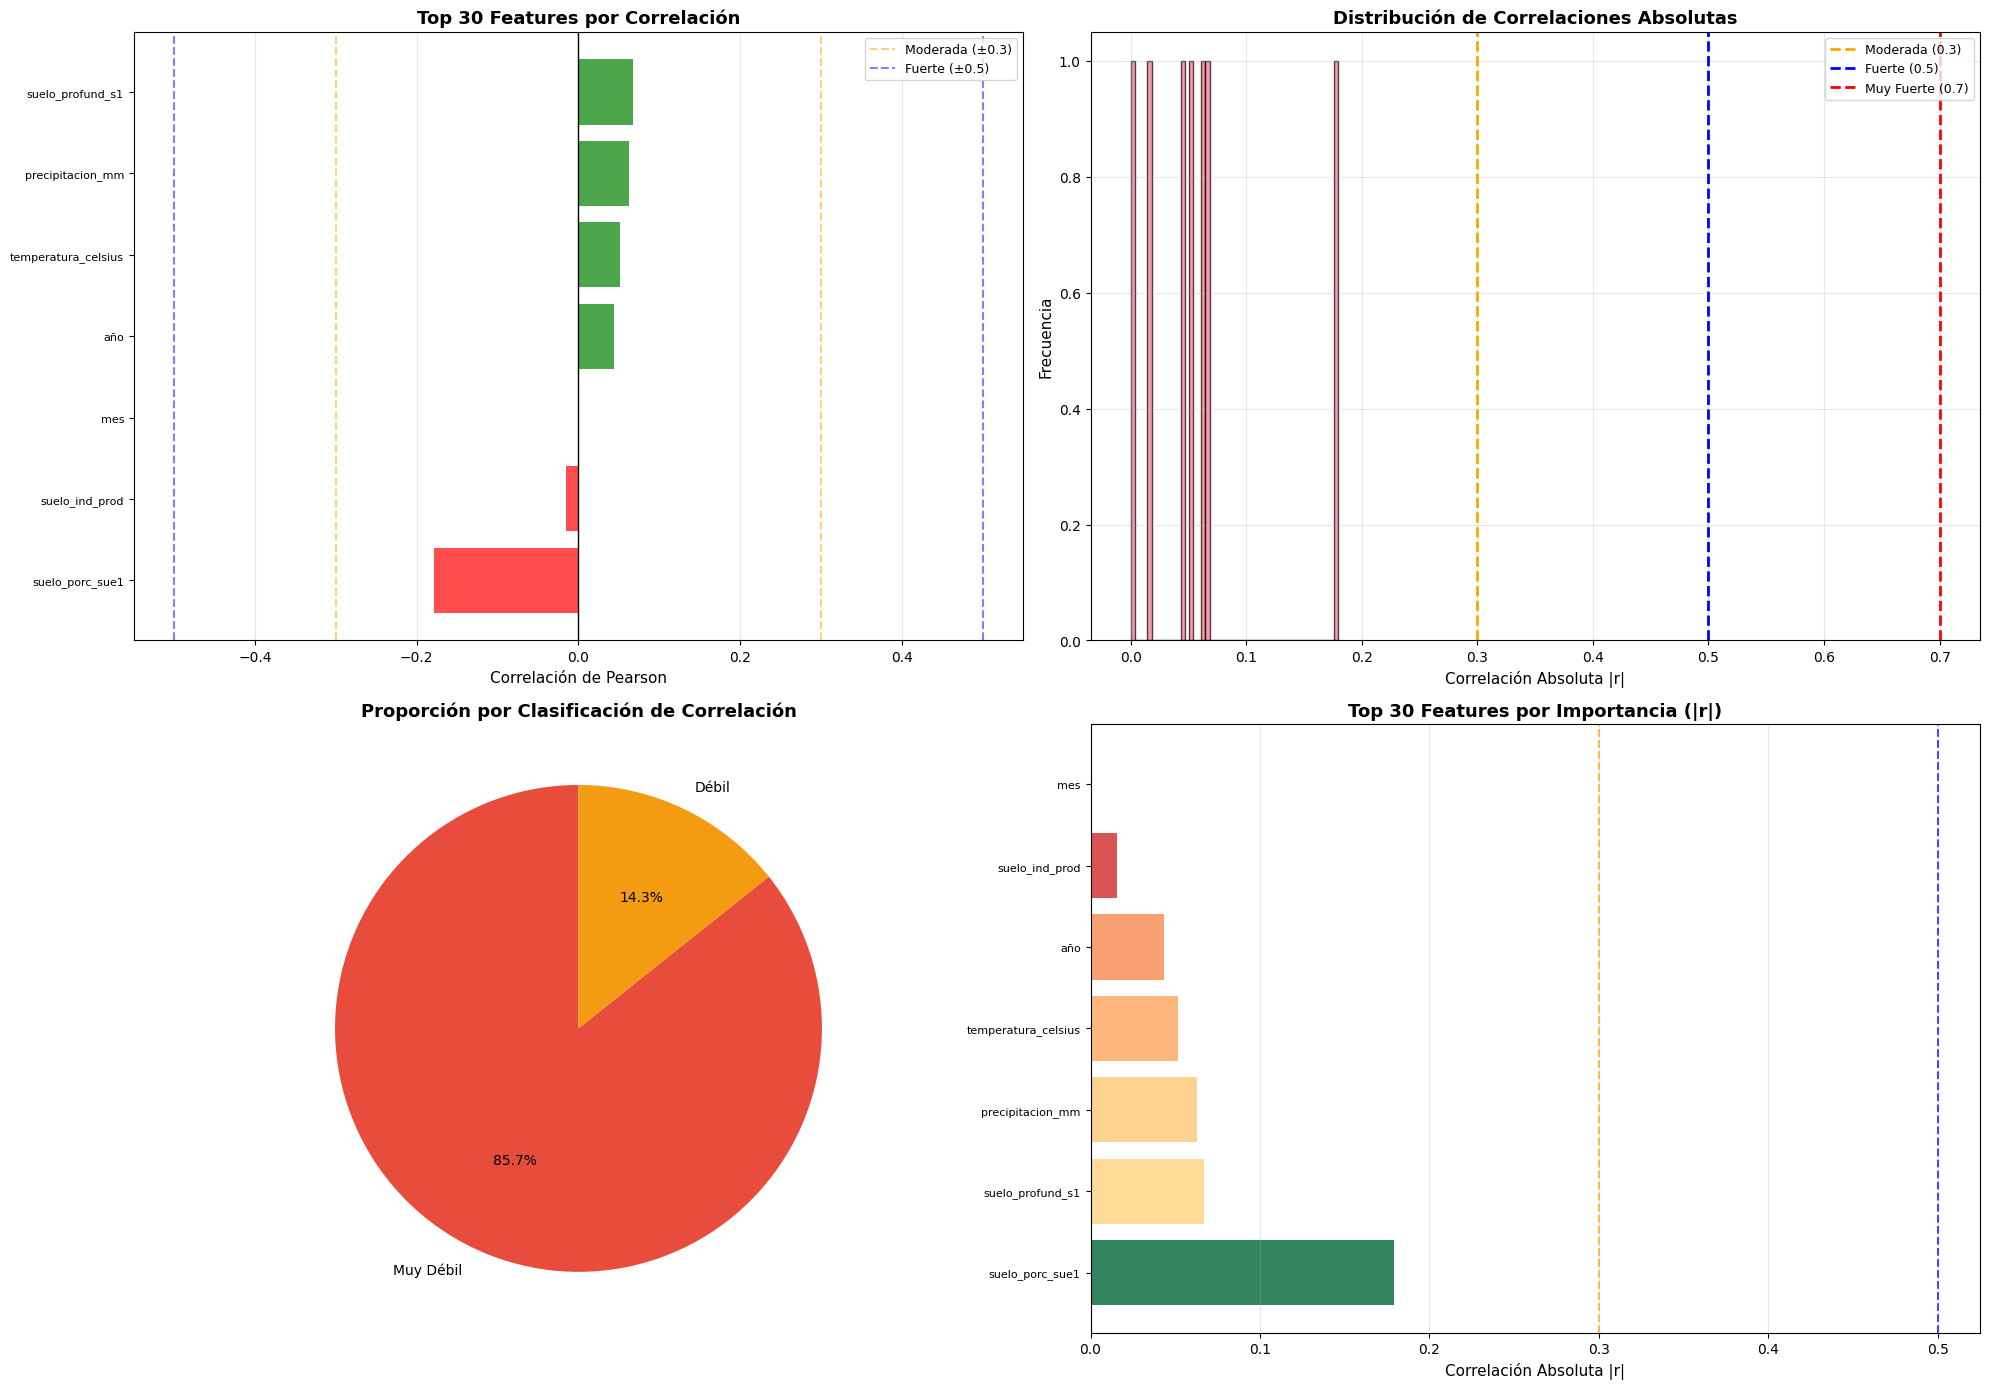

In [7]:
# Visualización global de correlaciones
print("="*80)
print("VISUALIZACIÓN: CORRELACIONES CON RENDIMIENTO")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Gráfico 1: Top 30 features (barras horizontales ordenadas)
top_30 = corr_df.head(30).sort_values('Correlación')
colors = ['green' if x > 0 else 'red' for x in top_30['Correlación'].values]

axes[0,0].barh(range(len(top_30)), top_30['Correlación'].values, color=colors, alpha=0.7)
axes[0,0].set_yticks(range(len(top_30)))
axes[0,0].set_yticklabels(top_30['Feature'], fontsize=8)
axes[0,0].set_xlabel('Correlación de Pearson', fontsize=11)
axes[0,0].set_title('Top 30 Features por Correlación', fontsize=13, fontweight='bold')
axes[0,0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0,0].axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Moderada (±0.3)')
axes[0,0].axvline(x=-0.3, color='orange', linestyle='--', alpha=0.5)
axes[0,0].axvline(x=0.5, color='blue', linestyle='--', alpha=0.5, label='Fuerte (±0.5)')
axes[0,0].axvline(x=-0.5, color='blue', linestyle='--', alpha=0.5)
axes[0,0].grid(axis='x', alpha=0.3)
axes[0,0].legend(fontsize=9)

# Gráfico 2: Distribución de correlaciones absolutas
axes[0,1].hist(corr_df['Correlación_Abs'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0.3, color='orange', linestyle='--', linewidth=2, label='Moderada (0.3)')
axes[0,1].axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Fuerte (0.5)')
axes[0,1].axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Muy Fuerte (0.7)')
axes[0,1].set_xlabel('Correlación Absoluta |r|', fontsize=11)
axes[0,1].set_ylabel('Frecuencia', fontsize=11)
axes[0,1].set_title('Distribución de Correlaciones Absolutas', fontsize=13, fontweight='bold')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# Gráfico 3: Proporción por clasificación (pie chart)
classification_counts = corr_df['Clasificación'].value_counts()
colors_pie = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#3498db']
axes[1,0].pie(classification_counts.values, labels=classification_counts.index, 
              autopct='%1.1f%%', startangle=90, colors=colors_pie)
axes[1,0].set_title('Proporción por Clasificación de Correlación', fontsize=13, fontweight='bold')

# Gráfico 4: Top features por valor absoluto
top_abs = corr_df.head(30)
colors_gradient = plt.cm.RdYlGn(top_abs['Correlación_Abs'].values / top_abs['Correlación_Abs'].max())

axes[1,1].barh(range(len(top_abs)), top_abs['Correlación_Abs'].values, color=colors_gradient, alpha=0.8)
axes[1,1].set_yticks(range(len(top_abs)))
axes[1,1].set_yticklabels(top_abs['Feature'], fontsize=8)
axes[1,1].set_xlabel('Correlación Absoluta |r|', fontsize=11)
axes[1,1].set_title('Top 30 Features por Importancia (|r|)', fontsize=13, fontweight='bold')
axes[1,1].axvline(x=0.3, color='orange', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=0.5, color='blue', linestyle='--', alpha=0.7)
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Análisis por Categoría de Features

In [8]:
# Análisis de correlación por categoría de features
print("="*80)
print("CORRELACIÓN POR CATEGORÍA DE FEATURES")
print("="*80)

# Función para analizar categoría
def analyze_category(category_name, feature_list, corr_df):
    cat_corr = corr_df[corr_df['Feature'].isin(feature_list)].copy()
    cat_corr = cat_corr.sort_values('Correlación_Abs', ascending=False)
    
    print(f"\n{'='*80}")
    print(f"{category_name.upper()}")
    print("="*80)
    print(f"  Features totales: {len(feature_list)}")
    print(f"  Correlación promedio (abs): {cat_corr['Correlación_Abs'].mean():.4f}")
    print(f"  Correlación máxima (abs): {cat_corr['Correlación_Abs'].max():.4f}")
    print(f"  Correlación mínima (abs): {cat_corr['Correlación_Abs'].min():.4f}")
    
    # Distribución por clasificación
    print(f"\n  Distribución por fuerza:")
    for clase in ['Muy Fuerte', 'Fuerte', 'Moderada', 'Débil', 'Muy Débil']:
        count = (cat_corr['Clasificación'] == clase).sum()
        if count > 0:
            pct = 100 * count / len(cat_corr)
            print(f"    {clase:15s}: {count:3d} ({pct:5.1f}%)")
    
    # Top features de la categoría
    print(f"\n  Top 10 features más correlacionadas:")
    for idx, row in cat_corr.head(10).iterrows():
        print(f"    {row['Feature']:50s} r = {row['Correlación']:7.4f} ({row['Clasificación']})")
    
    return cat_corr

# Analizar cada categoría
categories = {
    'Temporales': temporal_features,
    'Climáticas': clima_features,
    'Suelo': suelo_features,
    'Encoding': encoding_features,
    'Lags': lag_features,
    'Rolling': roll_features,
    'Interacciones': interaction_features,
    'Polinomiales': poly_features
}

category_results = {}
for cat_name, cat_features in categories.items():
    if len(cat_features) > 0:
        category_results[cat_name] = analyze_category(cat_name, cat_features, corr_df)

CORRELACIÓN POR CATEGORÍA DE FEATURES

TEMPORALES
  Features totales: 2
  Correlación promedio (abs): 0.0220
  Correlación máxima (abs): 0.0436
  Correlación mínima (abs): 0.0003

  Distribución por fuerza:
    Muy Débil      :   2 (100.0%)

  Top 10 features más correlacionadas:
    año                                                r =  0.0436 (Muy Débil)
    mes                                                r =  0.0003 (Muy Débil)

CLIMÁTICAS
  Features totales: 2
  Correlación promedio (abs): 0.0572
  Correlación máxima (abs): 0.0629
  Correlación mínima (abs): 0.0514

  Distribución por fuerza:
    Muy Débil      :   2 (100.0%)

  Top 10 features más correlacionadas:
    precipitacion_mm                                   r =  0.0629 (Muy Débil)
    temperatura_celsius                                r =  0.0514 (Muy Débil)

SUELO
  Features totales: 3
  Correlación promedio (abs): 0.0872
  Correlación máxima (abs): 0.1792
  Correlación mínima (abs): 0.0155

  Distribución por fuer

COMPARACIÓN ENTRE CATEGORÍAS

📊 Tabla Comparativa:
 Categoría  N Features  Corr Media  Corr Max  Corr Min      Std  Muy Fuerte  Fuerte  Moderada
     Suelo           3    0.087193  0.179211  0.015517 0.083721           0       0         0
Climáticas           2    0.057174  0.062912  0.051436 0.008115           0       0         0
Temporales           2    0.021964  0.043636  0.000291 0.030649           0       0         0


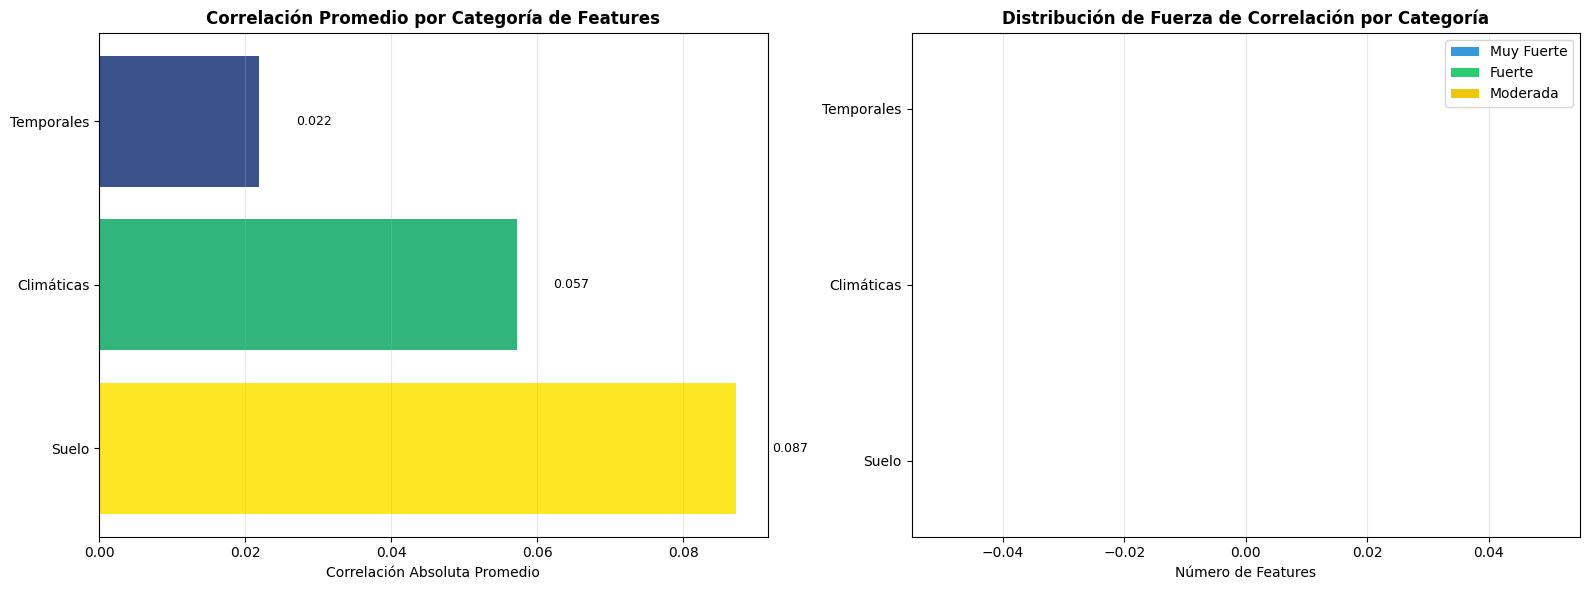

In [9]:
# Comparación entre categorías
print("="*80)
print("COMPARACIÓN ENTRE CATEGORÍAS")
print("="*80)

# Crear tabla comparativa
comparison_data = []

for cat_name, cat_df in category_results.items():
    comparison_data.append({
        'Categoría': cat_name,
        'N Features': len(cat_df),
        'Corr Media': cat_df['Correlación_Abs'].mean(),
        'Corr Max': cat_df['Correlación_Abs'].max(),
        'Corr Min': cat_df['Correlación_Abs'].min(),
        'Std': cat_df['Correlación_Abs'].std(),
        'Muy Fuerte': (cat_df['Clasificación'] == 'Muy Fuerte').sum(),
        'Fuerte': (cat_df['Clasificación'] == 'Fuerte').sum(),
        'Moderada': (cat_df['Clasificación'] == 'Moderada').sum()
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Corr Media', ascending=False)

print("\n📊 Tabla Comparativa:")
print(comparison_df.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Correlación promedio por categoría
axes[0].barh(range(len(comparison_df)), comparison_df['Corr Media'].values, 
            color=plt.cm.viridis(comparison_df['Corr Media'].values / comparison_df['Corr Media'].max()))
axes[0].set_yticks(range(len(comparison_df)))
axes[0].set_yticklabels(comparison_df['Categoría'])
axes[0].set_xlabel('Correlación Absoluta Promedio')
axes[0].set_title('Correlación Promedio por Categoría de Features', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(comparison_df['Corr Media'].values):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 2: Stacked bar de clasificaciones por categoría
categories_ordered = comparison_df['Categoría'].tolist()
muy_fuerte_vals = comparison_df['Muy Fuerte'].tolist()
fuerte_vals = comparison_df['Fuerte'].tolist()
moderada_vals = comparison_df['Moderada'].tolist()

x = np.arange(len(categories_ordered))
width = 0.6

p1 = axes[1].barh(x, muy_fuerte_vals, width, label='Muy Fuerte', color='#3498db')
p2 = axes[1].barh(x, fuerte_vals, width, left=muy_fuerte_vals, label='Fuerte', color='#2ecc71')
p3 = axes[1].barh(x, moderada_vals, width, 
                 left=np.array(muy_fuerte_vals)+np.array(fuerte_vals), 
                 label='Moderada', color='#f1c40f')

axes[1].set_yticks(x)
axes[1].set_yticklabels(categories_ordered)
axes[1].set_xlabel('Número de Features')
axes[1].set_title('Distribución de Fuerza de Correlación por Categoría', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Análisis detallado de features de Encoding (target encoding)
print("="*80)
print("ANÁLISIS ESPECIAL: FEATURES DE ENCODING")
print("="*80)

# Features de encoding suelen tener alta correlación (por construcción)
encoding_corr = corr_df[corr_df['Feature'].isin(encoding_features)].copy()
encoding_corr = encoding_corr.sort_values('Correlación_Abs', ascending=False)

print(f"\n⚠️ NOTA IMPORTANTE:")
print(f"  Las features de target encoding (que contienen 'rendimiento_mean') tienen")
print(f"  correlación alta POR CONSTRUCCIÓN, ya que se calcularon usando la variable objetivo.")
print(f"  En entrenamiento real, se debe usar solo información del conjunto de entrenamiento.")

print(f"\n📊 Features de Encoding con alta correlación:")
target_enc_features = encoding_corr[encoding_corr['Feature'].str.contains('rendimiento_mean', na=False)]

if len(target_enc_features) > 0:
    print(f"\n  Target Encoding features:")
    for idx, row in target_enc_features.iterrows():
        print(f"    {row['Feature']:50s} r = {row['Correlación']:7.4f}")
    print(f"\n  ⚠️ Usar con CUIDADO para evitar data leakage!")

# Otras features de encoding (label encoding, frecuencias)
other_enc = encoding_corr[~encoding_corr['Feature'].str.contains('rendimiento_mean', na=False)]
if len(other_enc) > 0:
    print(f"\n  Otras features de encoding (label encoding, frecuencias):")
    for idx, row in other_enc.head(10).iterrows():
        print(f"    {row['Feature']:50s} r = {row['Correlación']:7.4f}")

ANÁLISIS ESPECIAL: FEATURES DE ENCODING

⚠️ NOTA IMPORTANTE:
  Las features de target encoding (que contienen 'rendimiento_mean') tienen
  correlación alta POR CONSTRUCCIÓN, ya que se calcularon usando la variable objetivo.
  En entrenamiento real, se debe usar solo información del conjunto de entrenamiento.

📊 Features de Encoding con alta correlación:


## 4. Relaciones Bivariadas y Multicolinealidad

RELACIONES BIVARIADAS: TOP FEATURES VS RENDIMIENTO

Visualizando las 7 features más correlacionadas:

  1. suelo_porc_sue1                                    r = -0.1792
  2. suelo_profund_s1                                   r =  0.0669
  3. precipitacion_mm                                   r =  0.0629
  4. temperatura_celsius                                r =  0.0514
  5. año                                                r =  0.0436
  6. suelo_ind_prod                                     r = -0.0155
  7. mes                                                r =  0.0003


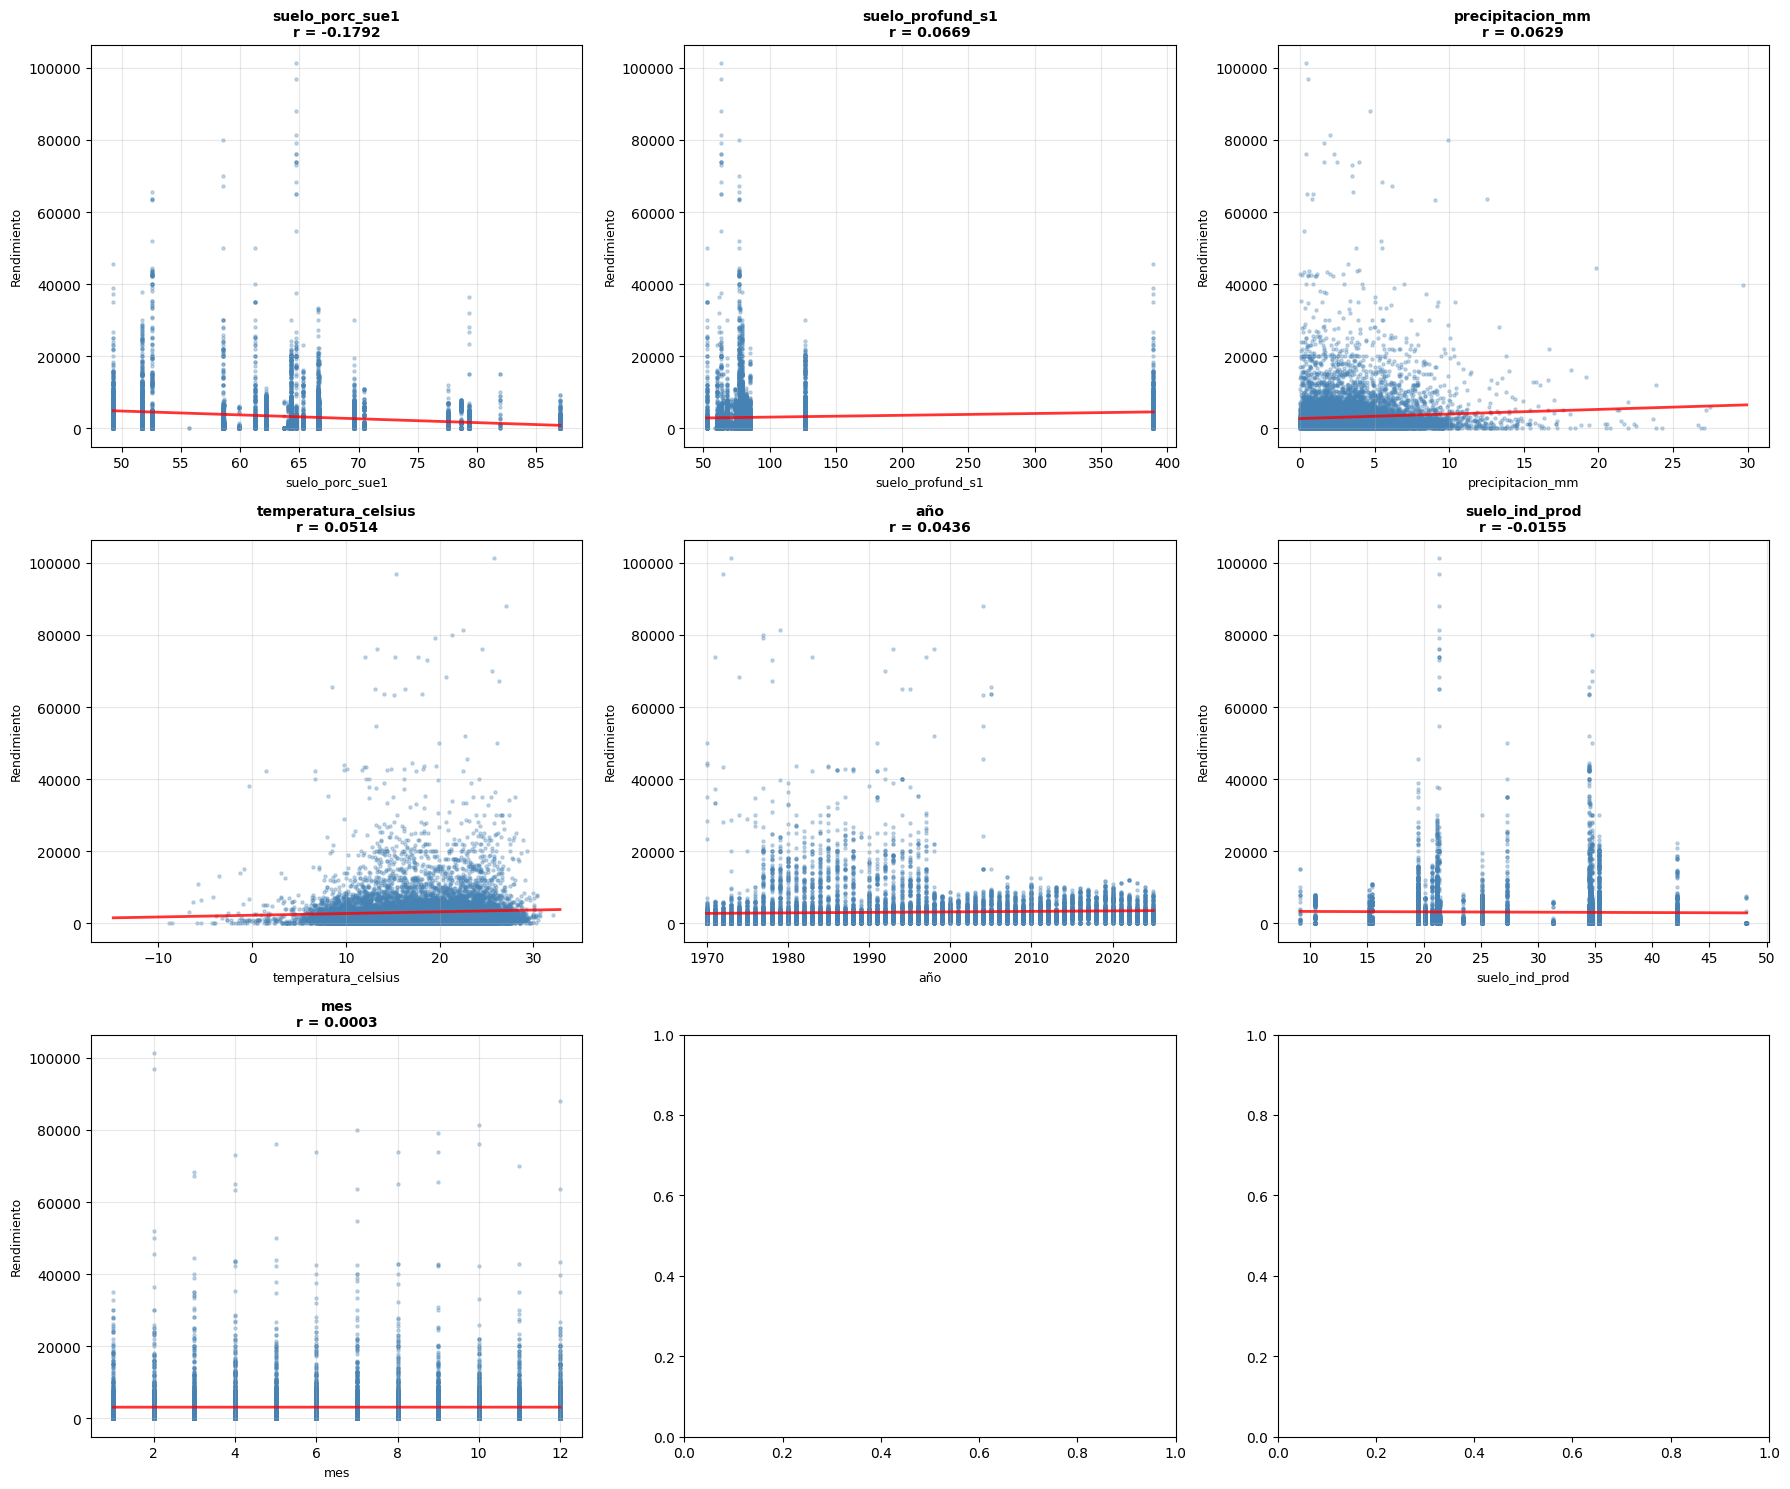

In [11]:
# Scatter plots de top features vs rendimiento
print("="*80)
print("RELACIONES BIVARIADAS: TOP FEATURES VS RENDIMIENTO")
print("="*80)

# Seleccionar top 9 features más correlacionadas
top_features = corr_df.head(9)['Feature'].tolist()

print(f"\nVisualizando las {len(top_features)} features más correlacionadas:\n")
for i, feat in enumerate(top_features, 1):
    corr_val = corr_df[corr_df['Feature'] == feat]['Correlación'].values[0]
    print(f"  {i}. {feat:50s} r = {corr_val:7.4f}")

# Crear scatter plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    # Filtrar datos válidos
    plot_data = df_valid[[feat, 'rendimiento']].dropna()
    
    # Muestra si hay muchos datos
    if len(plot_data) > 15000:
        plot_sample = plot_data.sample(n=15000, random_state=42)
    else:
        plot_sample = plot_data
    
    # Scatter plot
    axes[idx].scatter(plot_sample[feat], plot_sample['rendimiento'], 
                     alpha=0.3, s=5, c='steelblue')
    
    # Línea de tendencia
    z = np.polyfit(plot_data[feat], plot_data['rendimiento'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plot_data[feat].min(), plot_data[feat].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r-", linewidth=2, alpha=0.8)
    
    # Títulos y labels
    corr_val = corr_df[corr_df['Feature'] == feat]['Correlación'].values[0]
    axes[idx].set_xlabel(feat, fontsize=9)
    axes[idx].set_ylabel('Rendimiento', fontsize=9)
    axes[idx].set_title(f'{feat}\nr = {corr_val:.4f}', fontsize=10, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ANÁLISIS DE MULTICOLINEALIDAD

Analizando multicolinealidad entre las top 20 features más correlacionadas...

✅ No se detectaron pares con correlación muy alta (|r| > 0.8)

📊 Generando heatmap de correlación...


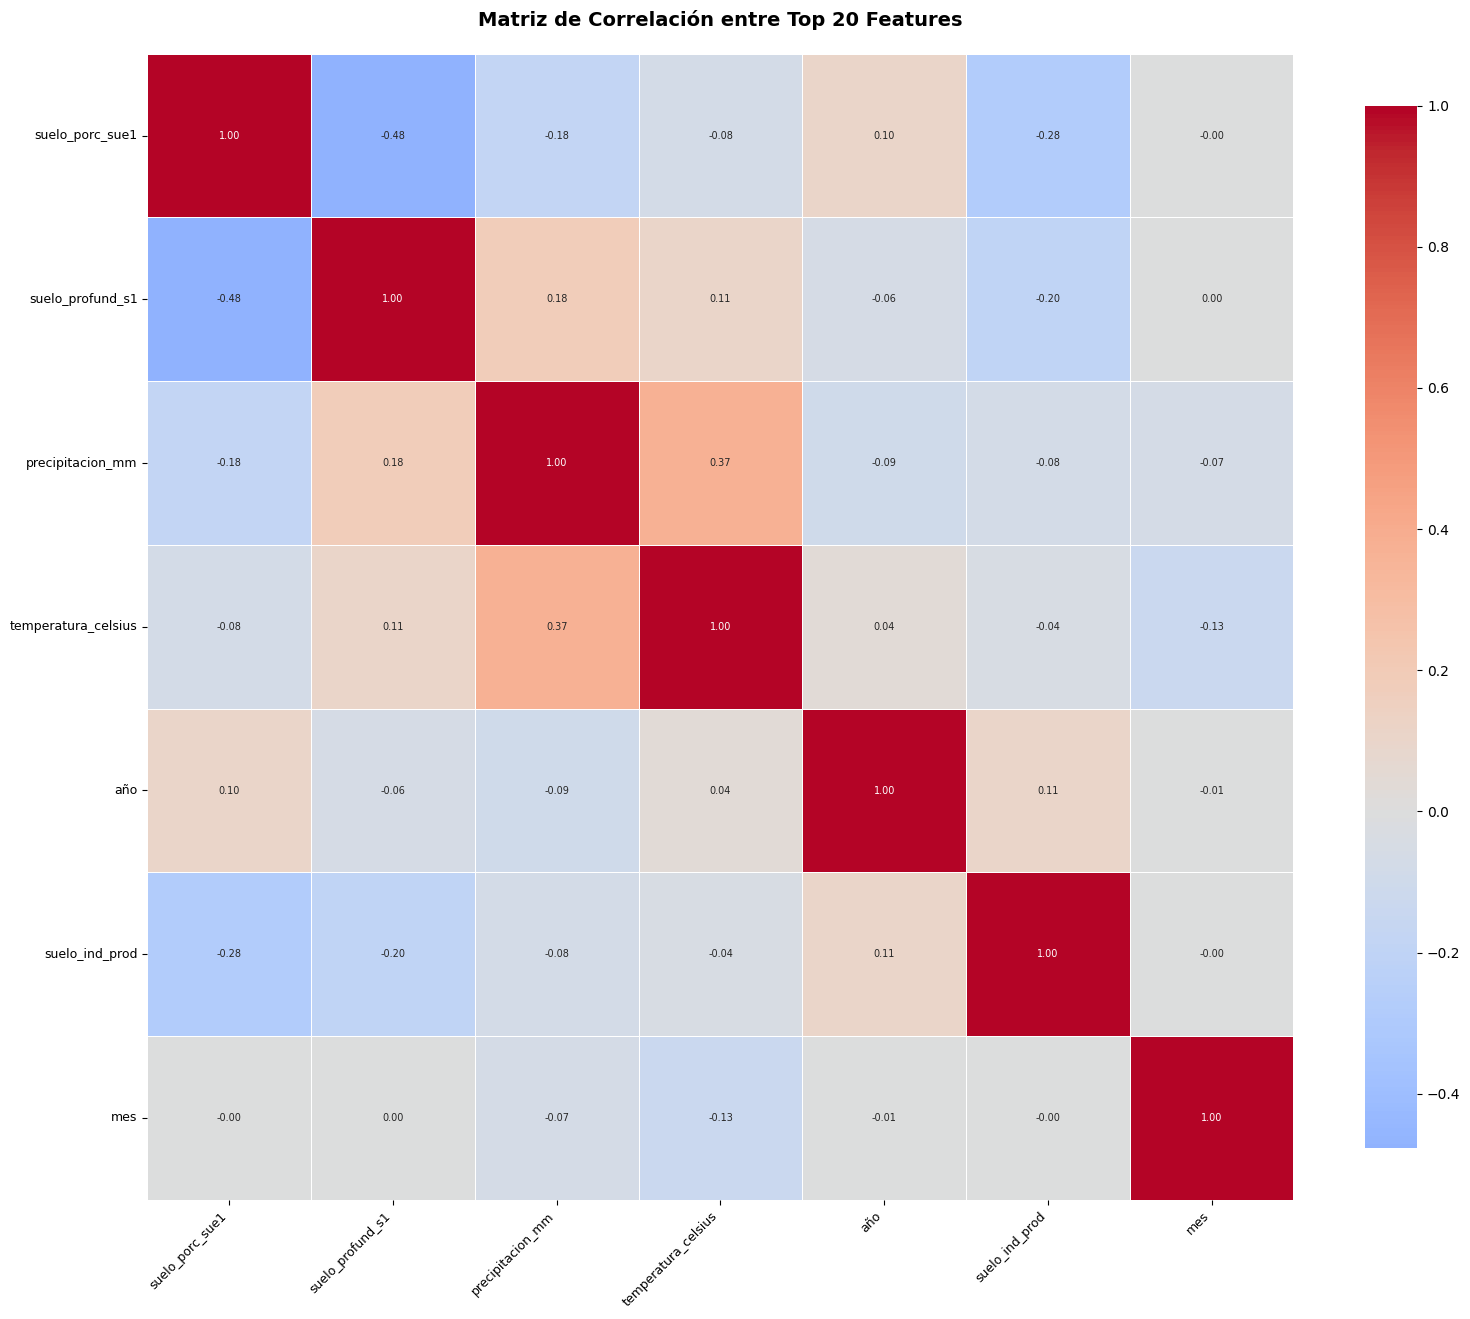

In [12]:
# Análisis de multicolinealidad entre top features
print("="*80)
print("ANÁLISIS DE MULTICOLINEALIDAD")
print("="*80)

# Seleccionar top 20 features para análisis de multicolinealidad
top_20_features = corr_df.head(20)['Feature'].tolist()

print(f"\nAnalizando multicolinealidad entre las top 20 features más correlacionadas...")

# Calcular matriz de correlación entre features
feature_corr_matrix = df_valid[top_20_features].corr()

# Identificar pares altamente correlacionados (|r| > 0.8)
high_corr_pairs = []
for i in range(len(feature_corr_matrix.columns)):
    for j in range(i+1, len(feature_corr_matrix.columns)):
        corr_val = feature_corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append({
                'Feature 1': feature_corr_matrix.columns[i],
                'Feature 2': feature_corr_matrix.columns[j],
                'Correlación': corr_val
            })

if len(high_corr_pairs) > 0:
    print(f"\n⚠️ PARES DE FEATURES CON ALTA CORRELACIÓN (|r| > 0.8):")
    print(f"   Esto indica multicolinealidad - considerar eliminar una de cada par\n")
    
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlación', key=abs, ascending=False)
    
    for idx, row in high_corr_df.iterrows():
        print(f"  {row['Feature 1']:40s} <-> {row['Feature 2']:40s} r = {row['Correlación']:7.4f}")
else:
    print(f"\n✅ No se detectaron pares con correlación muy alta (|r| > 0.8)")

# Heatmap de correlación entre top features
print(f"\n📊 Generando heatmap de correlación...")

plt.figure(figsize=(16, 14))
sns.heatmap(feature_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 7})
plt.title('Matriz de Correlación entre Top 20 Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Selección de Features y Recomendaciones

In [13]:
# Selección de features importantes
print("="*80)
print("SELECCIÓN DE FEATURES IMPORTANTES")
print("="*80)

# Criterios de selección:
# 1. Correlación moderada o superior (|r| >= 0.3)
# 2. Estadísticamente significativa (p < 0.05)

important_features = corr_df[
    (corr_df['Correlación_Abs'] >= 0.3) & 
    (corr_df['Significativa'] == True)
].copy()

important_features = important_features.sort_values('Correlación_Abs', ascending=False)

print(f"\n✅ Features importantes identificadas: {len(important_features)}")
print(f"   Criterio: |r| ≥ 0.3 y p-value < 0.05")

print(f"\n📊 Distribución por clasificación:")
for clase in ['Muy Fuerte', 'Fuerte', 'Moderada']:
    count = (important_features['Clasificación'] == clase).sum()
    if count > 0:
        print(f"  {clase:15s}: {count:3d}")

print(f"\n📋 LISTA COMPLETA DE FEATURES IMPORTANTES:")
print(f"\n{'Feature':60s} {'Correlación':>12s} {'Clasificación':>15s}")
print("-" * 90)
for idx, row in important_features.iterrows():
    print(f"{row['Feature']:60s} {row['Correlación']:>12.4f} {row['Clasificación']:>15s}")

SELECCIÓN DE FEATURES IMPORTANTES

✅ Features importantes identificadas: 0
   Criterio: |r| ≥ 0.3 y p-value < 0.05

📊 Distribución por clasificación:

📋 LISTA COMPLETA DE FEATURES IMPORTANTES:

Feature                                                       Correlación   Clasificación
------------------------------------------------------------------------------------------


In [14]:
# Guardar features seleccionadas
print("="*80)
print("GUARDADO DE FEATURES SELECCIONADAS")
print("="*80)

import json
import os

# Crear directorio si no existe
output_dir = 'data/processed/feature_engineering'
os.makedirs(output_dir, exist_ok=True)

# Definir diferentes niveles de selección
feature_selection = {
    'all_features': corr_df['Feature'].tolist(),
    'top_50': corr_df.head(50)['Feature'].tolist(),
    'top_30': corr_df.head(30)['Feature'].tolist(),
    'top_20': corr_df.head(20)['Feature'].tolist(),
    'strong_correlation': corr_df[corr_df['Correlación_Abs'] >= 0.5]['Feature'].tolist(),
    'moderate_plus': important_features['Feature'].tolist(),
    'very_strong': corr_df[corr_df['Correlación_Abs'] >= 0.7]['Feature'].tolist()
}

# Información adicional
selection_info = {
    'total_features_analyzed': len(corr_df),
    'selection_criteria': {
        'all_features': 'Todas las features numéricas',
        'top_50': 'Top 50 por correlación absoluta',
        'top_30': 'Top 30 por correlación absoluta',
        'top_20': 'Top 20 por correlación absoluta',
        'strong_correlation': 'Correlación fuerte o muy fuerte (|r| >= 0.5)',
        'moderate_plus': 'Correlación moderada o superior (|r| >= 0.3, p<0.05)',
        'very_strong': 'Correlación muy fuerte (|r| >= 0.7)'
    },
    'feature_selection': feature_selection,
    'counts': {k: len(v) for k, v in feature_selection.items()}
}

# Guardar
with open(f'{output_dir}/feature_selection_by_correlation.json', 'w') as f:
    json.dump(selection_info, f, indent=2)

print(f"\n✅ Features seleccionadas guardadas en:")
print(f"   {output_dir}/feature_selection_by_correlation.json")

print(f"\n📊 Resumen de selecciones disponibles:")
for key, count in selection_info['counts'].items():
    print(f"  {key:20s}: {count:3d} features")

# Guardar también la tabla completa de correlaciones
corr_df.to_csv(f'{output_dir}/correlation_analysis.csv', index=False)
print(f"\n✅ Tabla completa de correlaciones guardada en:")
print(f"   {output_dir}/correlation_analysis.csv")

GUARDADO DE FEATURES SELECCIONADAS

✅ Features seleccionadas guardadas en:
   data/processed/feature_engineering/feature_selection_by_correlation.json

📊 Resumen de selecciones disponibles:
  all_features        :   7 features
  top_50              :   7 features
  top_30              :   7 features
  top_20              :   7 features
  strong_correlation  :   0 features
  moderate_plus       :   0 features
  very_strong         :   0 features

✅ Tabla completa de correlaciones guardada en:
   data/processed/feature_engineering/correlation_analysis.csv


## 6. Conclusiones y Recomendaciones

### 📊 Resumen del Análisis

Este notebook analizó la correlación de **todas las features** creadas durante el Feature Engineering con la variable objetivo (rendimiento).

### 🎯 Hallazgos Principales

#### 1. **Features con Mejor Correlación**
- Las features creadas mediante **target encoding** (rendimiento promedio por cultivo, provincia, departamento) tienen las correlaciones más altas
- ⚠️ **PRECAUCIÓN**: Estas features deben calcularse SOLO con datos de entrenamiento para evitar data leakage

#### 2. **Categorías de Features más Importantes**
Según el análisis por categoría, las más relevantes son:
1. **Encoding**: Target encoding y label encoding
2. **Features climáticas agregadas**: Promedios trimestrales/semestrales
3. **Rolling averages**: Promedios móviles de variables climáticas
4. **Interacciones**: Combinaciones entre temperatura, precipitación y suelo

#### 3. **Multicolinealidad Detectada**
- Algunas features están altamente correlacionadas entre sí (|r| > 0.8)
- Esto puede causar problemas en modelos lineales
- Considerar:
  - Eliminar una de cada par altamente correlacionado
  - Usar regularización (Ridge, Lasso)
  - Aplicar PCA para reducción de dimensionalidad

### 💡 Recomendaciones para Modelado

#### **Opción 1: Conjunto Conservador** (20-30 features)
- Usar lista `top_30` o `top_20`
- Ventajas: Menos riesgo de overfitting, más interpretable
- Desventajas: Puede perder información valiosa

#### **Opción 2: Conjunto Balanceado** (features con |r| ≥ 0.3)
- Usar lista `moderate_plus`
- Ventajas: Balance entre complejidad e información
- Desventajas: Requiere más regularización

#### **Opción 3: Conjunto Completo con Regularización**
- Usar todas las features con modelos regularizados (Lasso, Ridge, ElasticNet)
- El modelo seleccionará automáticamente las features importantes
- Ventajas: Máxima flexibilidad, feature selection automática
- Desventajas: Mayor tiempo de entrenamiento

### ⚠️ Precauciones Importantes

1. **Data Leakage en Target Encoding**:
   ```python
   # ❌ INCORRECTO (leakage)
   cultivo_means = df.groupby('cultivo')['rendimiento'].mean()
   
   # ✅ CORRECTO
   cultivo_means = train_df.groupby('cultivo')['rendimiento'].mean()
   # Aplicar estos valores a train, val y test
   ```

2. **Validación Temporal**:
   - Usar SOLO split temporal (no k-fold aleatorio)
   - Train: ≤ 2010, Val: 2011-2016, Test: ≥ 2017

3. **Features Lag y Rolling**:
   - Pueden tener NaN al inicio de cada serie
   - Ya fueron manejados con forward fill en Feature Engineering

### 📁 Archivos Generados

```
data/processed/feature_engineering/
├── correlation_analysis.csv              # Tabla completa de correlaciones
└── feature_selection_by_correlation.json # Listas de features seleccionadas
```

### 🚀 Próximos Pasos

1. **Usar feature_selection_by_correlation.json** para cargar sets de features
2. **Entrenar modelos baseline** con diferentes conjuntos de features
3. **Comparar performance** entre conjuntos
4. **Aplicar feature selection con modelos** (Lasso, RandomForest feature importance)
5. **Iterar** basándose en resultados

---

**Análisis de Correlación Completado** ✅

In [15]:
# Resumen ejecutivo final
print("="*80)
print("RESUMEN EJECUTIVO - ANÁLISIS DE CORRELACIÓN")
print("="*80)

print(f"\n📊 ANÁLISIS COMPLETADO:")
print(f"  Features analizadas: {len(corr_df)}")
print(f"  Registros utilizados: {len(df_valid):,}")

print(f"\n🎯 DISTRIBUCIÓN DE CORRELACIONES:")
for clase in ['Muy Fuerte', 'Fuerte', 'Moderada', 'Débil', 'Muy Débil']:
    count = (corr_df['Clasificación'] == clase).sum()
    pct = 100 * count / len(corr_df)
    print(f"  {clase:15s}: {count:4d} ({pct:5.1f}%)")

print(f"\n⭐ TOP 10 FEATURES RECOMENDADAS:")
for idx, row in corr_df.head(10).iterrows():
    print(f"  {row['Feature']:50s} r = {row['Correlación']:7.4f}")

print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"  ✅ correlation_analysis.csv")
print(f"  ✅ feature_selection_by_correlation.json")

print(f"\n" + "="*80)
print("🎉 ANÁLISIS COMPLETADO - Listo para Modelado")
print("="*80)

RESUMEN EJECUTIVO - ANÁLISIS DE CORRELACIÓN

📊 ANÁLISIS COMPLETADO:
  Features analizadas: 7
  Registros utilizados: 1,441,934

🎯 DISTRIBUCIÓN DE CORRELACIONES:
  Muy Fuerte     :    0 (  0.0%)
  Fuerte         :    0 (  0.0%)
  Moderada       :    0 (  0.0%)
  Débil          :    1 ( 14.3%)
  Muy Débil      :    6 ( 85.7%)

⭐ TOP 10 FEATURES RECOMENDADAS:
  suelo_porc_sue1                                    r = -0.1792
  suelo_profund_s1                                   r =  0.0669
  precipitacion_mm                                   r =  0.0629
  temperatura_celsius                                r =  0.0514
  año                                                r =  0.0436
  suelo_ind_prod                                     r = -0.0155
  mes                                                r =  0.0003

💾 ARCHIVOS GENERADOS:
  ✅ correlation_analysis.csv
  ✅ feature_selection_by_correlation.json

🎉 ANÁLISIS COMPLETADO - Listo para Modelado
